[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/beykyle/jitr/blob/main/examples/notebooks/qepn_analyzing_power.ipynb)

On Colab the first `import exfor_tools` downloads and unpacks the EXFOR database, which takes a few minutes.

In [1]:
# Google Colab setup: installs jitr and this notebook's extra dependencies.
# Does nothing when the notebook is run anywhere else.
import sys

if "google.colab" in sys.modules:
    import subprocess

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "jitr", "exfor-tools"],
        check=True,
    )

# Analyzing power of the quasi-elastic $(\vec{p},n)$ reaction

In 1976 Gosset, Mayer and Escudié measured the differential analyzing power $A_y(\theta)$ of
the quasi-elastic $(p,n)$ reaction to the isobaric analog state (IAS) on nine targets, with a
22.8 MeV polarized proton beam at Saclay
([Phys. Rev. C **14**, 878](https://doi.org/10.1103/PhysRevC.14.878)).
Those data are EXFOR entry [O0669](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=51740&subID=O0669).

Their point was that $A_y$ is a far sharper probe of the Lane potential than the cross section is.
In the macroscopic Lane model the nucleon-nucleus optical potential splits into isoscalar and
isovector parts,

$$ U = U_0 + \frac{4}{A} U_1\, \vec{t} \cdot \vec{T}, $$

which for the proton-target, neutron-analog and neutron-target channels gives

$$ U_{pT} = U_0 - \frac{2 T_0}{A} U_1, \qquad
   U_{nA} = U_0 + \frac{2 (T_0 - 1)}{A} U_1, \qquad
   U_{nT} = U_0 + \frac{2 T_0}{A} U_1, $$

with $T_0 = (N - Z)/2$. The off-diagonal part of $U_1$ drives the charge-exchange transition
between $|T_0 T_0\rangle$ and its analog $|T_0, T_0 - 1\rangle$. Because the transition carries
$l = s = j = 0$, only two amplitudes survive — one conserving and one inverting the projectile
spin projection — and the analyzing power is

$$ A_y = \frac{2\,\mathrm{Im}(Y X^*)}{|X|^2 + |Y|^2}. $$

The spin-flip amplitude $Y$ is built from the *difference* between the $j = l + \tfrac{1}{2}$ and
$j = l - \tfrac{1}{2}$ radial matrix elements. 

This notebook solves the two coupled Lane channels exactly with
[`jitr.xs.lane_pn`](https://jitr.readthedocs.io/en/latest/autoapi/jitr/xs/lane_pn/index.html)
rather than in DWBA, and propagates the posteriors of three uncertainty-quantified global optical
potentials — KDUQ, WLH and CHUQ — plus a deterministic JLMB calculation, through to $A_y$ for all
nine targets.

Notw that, while $^{49}$Ti, $^{117}$Sn and $^{165}$Ho all have non-zero ground-state spin, the measured transitions transfer no angular momentum, so the target spin is a spectator and the spin-1/2 geometry used here is still reasonable.

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import periodictable

import jitr
from jitr.folding import ILDAFolder
from jitr.folding.jlm import (
    lambda_v0,
    lambda_v1,
    lambda_vso,
    lambda_w0,
    lambda_w1,
    lambda_wso,
    potential_JLMB,
    spin_orbit_jlmb,
)
from jitr.optical_potentials import chuq, kduq, wlh
from jitr.utils.density import density_table
from jitr.xs import lane_pn, quasielastic_pn

# set JITR_QUICK=1 to thin the posterior draws; used by the CI notebook run
QUICK = os.environ.get("JITR_QUICK", "0") == "1"

## Pulling the measurements from EXFOR

Each of the nine targets is a subentry of O0669, tabulated as an analyzing power against the center-of-mass angle, together with the excitation energy of the analog state in the residual nucleus. That excitation energy is what fixes the outgoing neutron energy, so we read it from the entry to set the kinematics in the exit channels.

In [3]:
import exfor_tools
print(exfor_tools.__version__)

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31
1.3


In [4]:
from exfor_tools import ExforEntry
from exfor_tools.reaction import Reaction as ExforReaction
# the nine targets of Table I, in the order the paper presents them
TARGETS = [
    (49, 22),
    (56, 26),
    (64, 28),
    (70, 30),
    (90, 40),
    (96, 40),
    (117, 50),
    (165, 67),
    (208, 82),
]
PROTON, NEUTRON = (1, 1), (1, 0)


def nuclide(A, Z):
    return rf"$^{{{A}}}${periodictable.elements[Z].symbol}"


datasets = []
for A, Z in TARGETS:
    entry = ExforEntry(
        "O0669",
        ExforReaction(
            target=(A, Z), projectile=PROTON, product=NEUTRON, residual=(A, Z + 1)
        ),
        quantity="Ay",
    )
    (measurement,) = entry.measurements
    datasets.append(
        {
            "A": A,
            "Z": Z,
            "name": f"{A}{periodictable.elements[Z].symbol}",
            "residual_name": f"{A}{periodictable.elements[Z + 1].symbol}",
            "label": nuclide(A, Z),
            "subentry": measurement.subentry,
            "E_lab": measurement.Einc,
            "E_IAS": measurement.Ex,
            "theta": measurement.x,
            "Ay": measurement.y,
            "Ay_err": measurement.statistical_err,
        }
    )

print(entry.bibtex())

@article{JGosset1976_O0669001,
  author = {J.Gosset and B.Mayer and J.L.Escudie},
  title = {Quasielastic (P,N) Reactions Induced By Polarized Protons.},
  journal = {Physical Review, Part C, Nuclear Physics},
  year = {1976},
  volume = {14},
  pages = {878},
  note = {EXFOR reference: Physical Review, Part C, Nuclear Physics 14, 878 (1976); EXFOR subent: O0669001}
}


In [5]:
header = f"{'target':>8} {'residual':>10} {'subentry':>10} {'E_IAS [MeV]':>12} {'points':>7} {'angular range [deg]':>22}"
print(header)
print("-" * len(header))
for d in datasets:
    angles = f"{d['theta'][0]:.1f} - {d['theta'][-1]:.1f}"
    print(
        f"{d['name']:>8} {d['residual_name']:>10} {d['subentry']:>10} "
        f"{d['E_IAS']:>12.2f} {len(d['theta']):>7} {angles:>22}"
    )
print(
    f"\n{sum(len(d['theta']) for d in datasets)} points, all at E_p = {datasets[0]['E_lab']} MeV"
)

  target   residual   subentry  E_IAS [MeV]  points    angular range [deg]
--------------------------------------------------------------------------
    49Ti        49V   O0669002         5.36      18           16.6 - 103.2
    56Fe       56Co   O0669003         3.51      23           15.7 - 125.1
    64Ni       64Cu   O0669004         6.70      19           16.7 - 106.4
    70Zn       70Ga   O0669005         8.12      20           16.0 - 114.3
    90Zr       90Nb   O0669006         5.03      22           15.4 - 124.3
    96Zr       96Nb   O0669007        11.07      18            14.4 - 98.7
   117Sn      117Sb   O0669008        11.18      17            15.0 - 94.9
   165Ho      165Er   O0669009        15.49       8            16.9 - 61.0
   208Pb      208Bi   O0669010        15.33       4            17.3 - 31.4

149 points, all at E_p = 22.8 MeV


## Compiling one coupled-channels workspace per target

`jitr.xs.lane_pn.Workspace` solves the two-channel problem

$$ \left[T_l + U_{pp} - E_p\right] u_p + U_1 u_n = 0, \qquad
   \left[T_l + U_{nn} - E_n\right] u_n + U_1 u_p = 0 $$

for every $(l, j)$, with an incoming wave in the proton channel only.

In [6]:
E_LAB = 22.8
LMAX = 25
ANGLES = np.radians(np.linspace(1.0, 180.0, 180))

solvers = {}
for d in datasets:
    A, Z = d["A"], d["Z"]
    reaction = jitr.reactions.Reaction(
        target=(A, Z), projectile=PROTON, product=NEUTRON, residual=(A, Z + 1)
    )
    # "El" so that the neutron potential is evaluated for n + residual
    exit_reaction = jitr.reactions.Reaction(
        target=(A, Z + 1), projectile=NEUTRON, process="El"
    )
    kinematics_entrance = reaction.kinematics(E_LAB)
    kinematics_exit = reaction.kinematics_exit(
        kinematics_entrance, residual_excitation_energy=d["E_IAS"]
    )

    a = jitr.utils.interaction_range(A) * kinematics_entrance.k + 2 * np.pi
    nbasis = jitr.utils.suggested_basis_size(a)
    solver = solvers.setdefault(nbasis, jitr.rmatrix.Solver(nbasis))

    d.update(
        reaction=reaction,
        exit_reaction=exit_reaction,
        kinematics_entrance=kinematics_entrance,
        kinematics_exit=kinematics_exit,
        nbasis=nbasis,
        channel_radius_fm=a / kinematics_entrance.k,
        workspace=lane_pn.Workspace(
            reaction,
            kinematics_entrance,
            kinematics_exit,
            solver,
            ANGLES,
            LMAX,
            a / kinematics_entrance.k,
        ),
    )

for d in datasets:
    print(
        f"{d['name']:>8}  E_n = {d['kinematics_exit'].Elab:5.2f} MeV  "
        f"a = {d['channel_radius_fm']:5.2f} fm  nbasis = {d['nbasis']:2d}"
    )

    49Ti  E_n = 15.92 MeV  a = 10.47 fm  nbasis = 20
    56Fe  E_n = 13.78 MeV  a = 10.66 fm  nbasis = 20
    64Ni  E_n = 13.50 MeV  a = 10.85 fm  nbasis = 20
    70Zn  E_n = 13.11 MeV  a = 10.99 fm  nbasis = 20
    90Zr  E_n = 10.74 MeV  a = 11.40 fm  nbasis = 20
    96Zr  E_n = 10.99 MeV  a = 11.52 fm  nbasis = 20
   117Sn  E_n =  8.96 MeV  a = 11.88 fm  nbasis = 20
   165Ho  E_n =  6.05 MeV  a = 12.58 fm  nbasis = 25
   208Pb  E_n =  3.72 MeV  a = 13.10 fm  nbasis = 25


## Propagating the optical model posteriors

Let's propagate the KDUQ, WLH and CHUQ posteriors through the $(p,n)$
$A_y$.

Nothing here is a fit to these data: the potentials were calibrated to elastic scattering, and the Lane transition potential is taken to be the isovector difference

$$ U_1(E) = -\left(U_n(E - Q - E_x) - U_p(E)\right) \frac{\sqrt{|N - Z|}}{N - Z - 1}, $$

evaluated separately for the central and spin-orbit terms — so the isovector spin-orbit form factor that the analyzing power is sensitive to comes entirely from the difference between the proton and neutron spin-orbit potentials of each global parameterization. Note that the neutron and proton potentials going into $U_1$ are evaluated at the energies of their respective channels.

CHUQ deserves a word: CH89 is Lane-consistent by construction, so it is the one built-in whose proton and neutron potentials really are the $U_{pT}$ and $U_{nA}$ of the equations above, and whose difference therefore really is $U_1$. For KDUQ and WLH the same construction is an approximation, and the diagonal potentials may already absorb part of the coupling.

In [7]:
from tqdm import tqdm

OMPS = {
    "KDUQ": (
        kduq.KDUQ(PROTON),
        kduq.KDUQ(NEUTRON),
        kduq.get_samples(PROTON),
        kduq.get_samples(NEUTRON),
    ),
    "WLH": (
        wlh.WLH(PROTON),
        wlh.WLH(NEUTRON),
        wlh.get_samples(PROTON),
        wlh.get_samples(NEUTRON),
    ),
    # CH89 is Lane consistent: one parameter set serves both projectiles
    "CHUQ": (chuq.CHUQ(), chuq.CHUQ(), chuq.get_samples(), chuq.get_samples()),
}


def propagate(omp_p, omp_n, samples_p, samples_n):
    n_draws = min(len(samples_p), len(samples_n))
    if QUICK:
        n_draws = min(n_draws, 50)

    bands = []
    for d in tqdm(datasets):
        workspace = d["workspace"]
        rgrid = workspace.radial_grid()
        Ay = np.zeros((len(ANGLES), n_draws))
        dsdo = np.zeros((len(ANGLES), n_draws))
        for j in range(n_draws):
            U_p, U_p_so, U_coulomb = omp_p(
                rgrid, d["reaction"], d["kinematics_entrance"], *samples_p[j]
            )
            U_n, U_n_so, _ = omp_n(
                rgrid, d["exit_reaction"], d["kinematics_exit"], *samples_n[j]
            )
            _, S = workspace.rsmatrix(U_coulomb, U_p, U_p_so, U_n, U_n_so)
            observables = workspace.observables_from_smatrix(S)
            Ay[:, j] = observables.Ay
            dsdo[:, j] = observables.dsdo
        bands.append(
            {
                "Ay": np.percentile(Ay, [16, 84], axis=1),
                "Ay_median": np.median(Ay, axis=1),
                "dsdo": np.percentile(dsdo, [16, 84], axis=1),
                "dsdo_median": np.median(dsdo, axis=1),
            }
        )
    return n_draws, bands

In [8]:
predictions = {}
for name, args in OMPS.items():
    n_draws, bands = propagate(*args)
    predictions[name] = bands
    print(f"{name}: {n_draws} posterior draws x {len(datasets)} targets")

  0%|                                                                         | 0/9 [00:00<?, ?it/s]/home/kyle/umich/jitr/src/jitr/optical_potentials/kduq.py:470: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|█████████████████████████████████████████████████████████████████| 9/9 [00:26<00:00,  2.90s/it]


KDUQ: 416 posterior draws x 9 targets


100%|█████████████████████████████████████████████████████████████████| 9/9 [00:45<00:00,  5.01s/it]


WLH: 1000 posterior draws x 9 targets


100%|█████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.04s/it]

CHUQ: 208 posterior draws x 9 targets


## A semi-microscopic comparison: JLMB

JLMB is a different kind of potential: a local-density folding of the Jeukenne-Lejeune-Mahaux
nuclear-matter *g*-matrix over a Gogny D1M density, with energy-dependent normalizations
$\lambda_V, \lambda_W, \lambda_{V_1}, \lambda_{W_1}$ and a Scheerbaum spin-orbit form factor. It is
the one potential here with a genuine isovector form factor rather than one obtained by
differencing.

It is not uncertainty quantified, so it contributes a single curve, not a band.

In [9]:
def jlmb_potentials(d):
    workspace = d["workspace"]
    rgrid = workspace.radial_grid()
    folder = ILDAFolder(r_max=15.0, n_quad=200)

    def channel(A, Z, projectile, energy, coulomb):
        table = density_table(A, Z, model="d1m")
        rho_n = folder.interp_to_quad(table.radial_grid, table.neutron_density_grid)
        rho_p = folder.interp_to_quad(table.radial_grid, table.proton_density_grid)
        V_C_quad = folder.V_coulomb(rho_p) if coulomb else None
        V, W = potential_JLMB(
            folder,
            rho_n,
            rho_p,
            projectile,
            (A, Z),
            energy,
            V_C=V_C_quad,
            parameterization="talys",
            lambda_V=float(lambda_v0(energy)),
            lambda_W=float(lambda_w0(energy, mode=0)),
            lambda_V1=float(lambda_v1(energy)),
            lambda_W1=float(lambda_w1(energy, mode=0)),
            t_r=1.25,
            t_i=1.35,
            r_out=rgrid,
        )
        spin_orbit = (
            float(lambda_vso(energy)) + 1j * float(lambda_wso(energy))
        ) * spin_orbit_jlmb(folder.r_q, rho_n, rho_p, projectile, r_out=rgrid)
        coulomb_out = folder.V_coulomb(rho_p, r_out=rgrid) if coulomb else None
        return (
            np.asarray(V + 1j * W, dtype=np.complex128),
            np.asarray(spin_orbit, dtype=np.complex128),
            (
                None
                if coulomb_out is None
                else np.asarray(coulomb_out, dtype=np.complex128)
            ),
        )

    U_p, U_p_so, U_coulomb = channel(
        d["A"], d["Z"], PROTON, d["kinematics_entrance"].Elab, coulomb=True
    )
    U_n, U_n_so, _ = channel(
        d["A"], d["Z"] + 1, NEUTRON, d["kinematics_exit"].Elab, coulomb=False
    )
    return U_coulomb, U_p, U_p_so, U_n, U_n_so


jlmb = []
for d in datasets:
    jlmb.append(d["workspace"].observables(*jlmb_potentials(d)))
print(f"JLMB evaluated for {len(jlmb)} targets")

JLMB evaluated for 9 targets


## Plot the measurements against the calculations

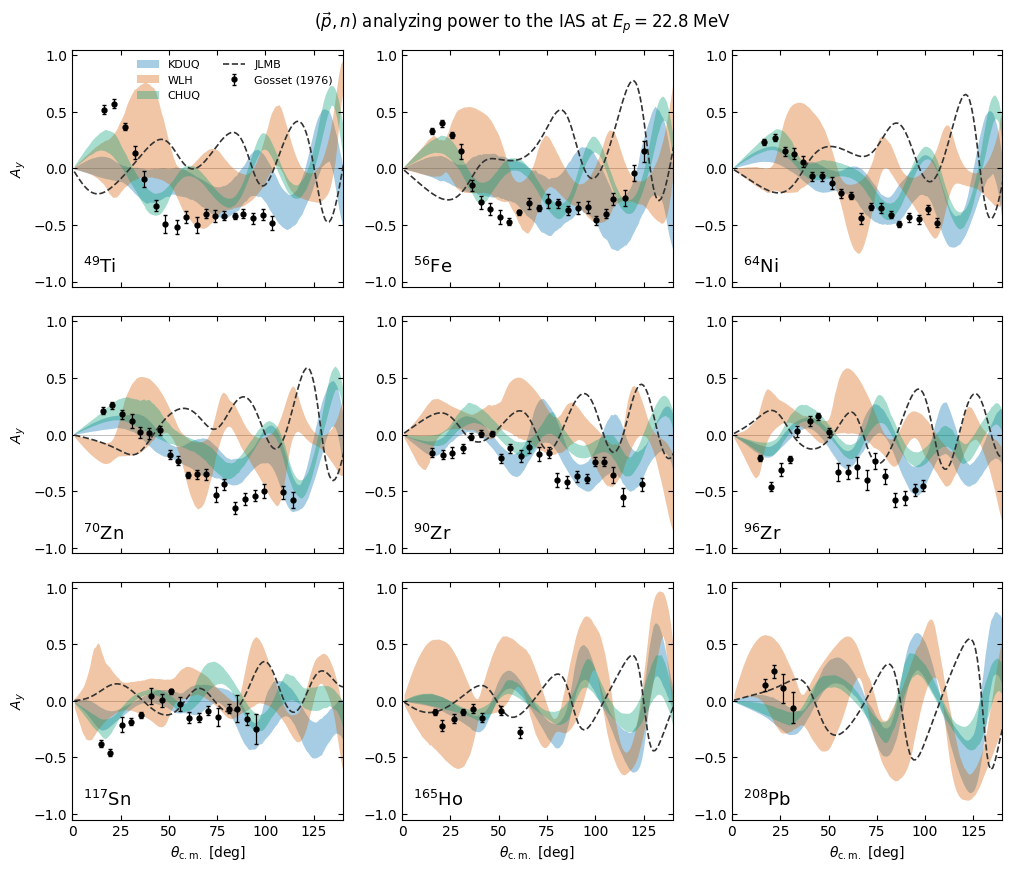

In [10]:
BANDS = {"KDUQ": "#0072B2", "WLH": "#D55E00", "CHUQ": "#009E73"}
JLMB_INK = "#333333"
angles_deg = np.degrees(ANGLES)


def grid_figure(ylabel):
    fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
    fig.subplots_adjust(hspace=0.12, wspace=0.22)
    for ax in axes[-1]:
        ax.set_xlabel(r"$\theta_{\rm c.m.}$ [deg]")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)
    for ax in axes.flat:
        ax.set_xlim(0, 140)
        ax.tick_params(direction="in", top=True, right=True)
        for side in ax.spines.values():
            side.set_linewidth(0.8)
    return fig, axes


fig, axes = grid_figure(r"$A_y$")
for i, (ax, d, curve) in enumerate(zip(axes.flat, datasets, jlmb, strict=True)):
    for name, color in BANDS.items():
        lo, hi = predictions[name][i]["Ay"]
        ax.fill_between(angles_deg, lo, hi, color=color, alpha=0.35, lw=0, label=name)
        #ax.plot(angles_deg, predictions[name][i]["Ay_median"], color=color, lw=1.2)
    ax.plot(angles_deg, curve.Ay, color=JLMB_INK, lw=1.2, ls="--", label="JLMB")
    ax.errorbar(
        d["theta"],
        d["Ay"],
        yerr=d["Ay_err"],
        fmt="o",
        ms=3.5,
        color="k",
        lw=0.9,
        capsize=1.5,
        label="Gosset (1976)",
    )
    ax.axhline(0.0, color="0.75", lw=0.7, zorder=0)
    ax.set_ylim(-1.05, 1.05)
    ax.text(0.04, 0.06, d["label"], transform=ax.transAxes, fontsize=13)

axes[0, 0].legend(loc="upper right", fontsize=8, frameon=False, ncols=2)
fig.suptitle(r"$(\vec{p},n)$ analyzing power to the IAS at $E_p = 22.8$ MeV", y=0.92)
plt.show()